In [1]:
import torch

In [2]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [3]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: Come, sister,--cousin, I would say--pray, pardon me.
Size of dataset: 40001 lines


In [4]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [5]:
import torch
import torch.nn.functional as F

### Create data set ###

train_frac = 0.95
seq_length = 75

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_length
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

split = int(train_frac * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

print('Example shape:', Xtr[0].shape, '=>', Ytr[0].shape)
print('Amount of train examples:', len(Xtr))

Example shape: torch.Size([75]) => torch.Size([75])
Amount of train examples: 1059624


In [6]:
import torch.nn as nn

emb_dim = 60
hidden_size = 128
num_layers = 3

class RNN(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.dim() == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)



model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 36605


In [7]:
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
import torch.nn.functional as F

### Train model ###
epochs = 50000
batch_size = 64
eval_batch_size = 9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []

from tqdm import trange
for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size) # Initialize hidden state
    output, _ = model(Xb, hidden)          # Do the forward pass
    loss = criterion(output, Yb)           # Calculate the loss
    optimizer.zero_grad()                  # Reset parameters
    loss.backward()                        # Backpropagation
    optimizer.step()                       # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
            
            # Log data
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())

# Print final results
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:', round(test_loss.item(), 3))

100%|██████████| 50000/50000 [01:42<00:00, 489.31it/s]

Final training loss: 1.464
Final test loss: 1.766


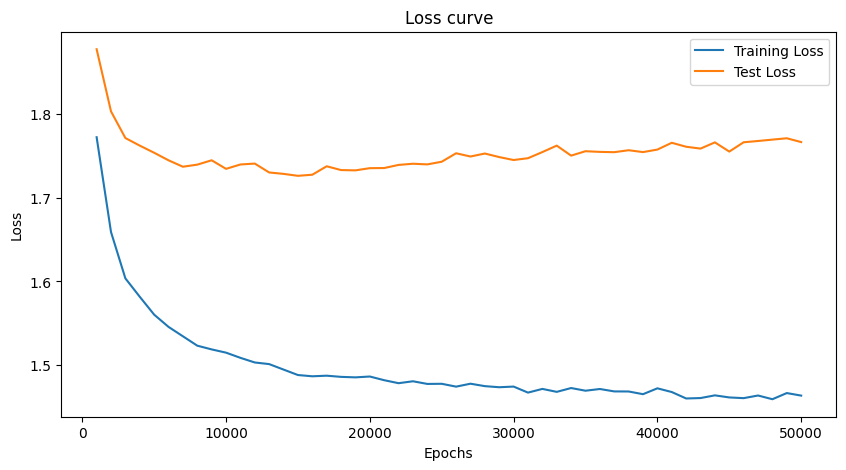

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
### Use model ###

@torch.inference_mode()
def evaluate(model, start='\n', length=1000):
    model.eval()

    hidden = model.init_hidden()
    prime_input = torch.tensor([[char_to_num[c] for c in start]])
    predicted = start

    # Build up hidden state with input text
    for i in range(len(start) - 1):
        _, hidden = model(prime_input[i].to(device), hidden)

    # Generate new sequence based on hidden state
    input = prime_input[-1]
    for i in range(length):
        output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output, dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix
    
    return predicted
    
print(evaluate(model))


Grath it before sworses,
Thy vain very couldone upon his sword it!
What was profeity-quanionce or he have in a place. He rusy he spale.

DUKE VINCENTIO:
Thou art neeparding confemon you, live:
O' no head; hadness' plain myself, 'tis on them no to's body:
I have chide wrong'd on thy master doth will it is Greased up: but on his mighty sun yrulist it, and her Clarence, sir, the wrath play'd Richmond dinter, and age, there' sounded
Ay. For black affected,
It is so, and to entrednes and Cotest the flower
Shot the kind uscrearing stam to doing,
Nor said,
Thy ships him in you, have nature to many presence o'er us a let this, we have enough thou well;
Tever at would first was livey, command gondood dispart us thereo-deed Aumerle, and see, and to the paly; as mistrest spate me. If not made you live to him.'
Sheep he consul danchbrowish,
He?

Messenged:
Thou shamesh deard's day.

Nurse.

CLARENCE:
He shall foney and my poor dreeds.

POMPEY:
Twenty but all the croved to the mother up your griev